# Medical Insurance Cost Prediction

**Goal:** predict `charges` (medical insurance cost) from age, sex, BMI, number of children, smoker status, and region.

**Dataset:** `insurance.csv` (Kaggle — Medical Cost Personal Datasets)

**Plan:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Data cleaning (duplicates, incorrect values, outliers)
4. Feature encoding & scaling
5. Train three models: Linear Regression, Random Forest, XGBoost
6. Compare models on R²
7. Save the best model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 1. Load & Inspect the Data

In [2]:
path = r'D:\AI\MasterClass\Projects\new_prj'
df = pd.read_csv(path + '\insurance.csv')
print('Shape:', df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## 2. Exploratory Data Analysis

### 2.1 Distributions of the numeric features

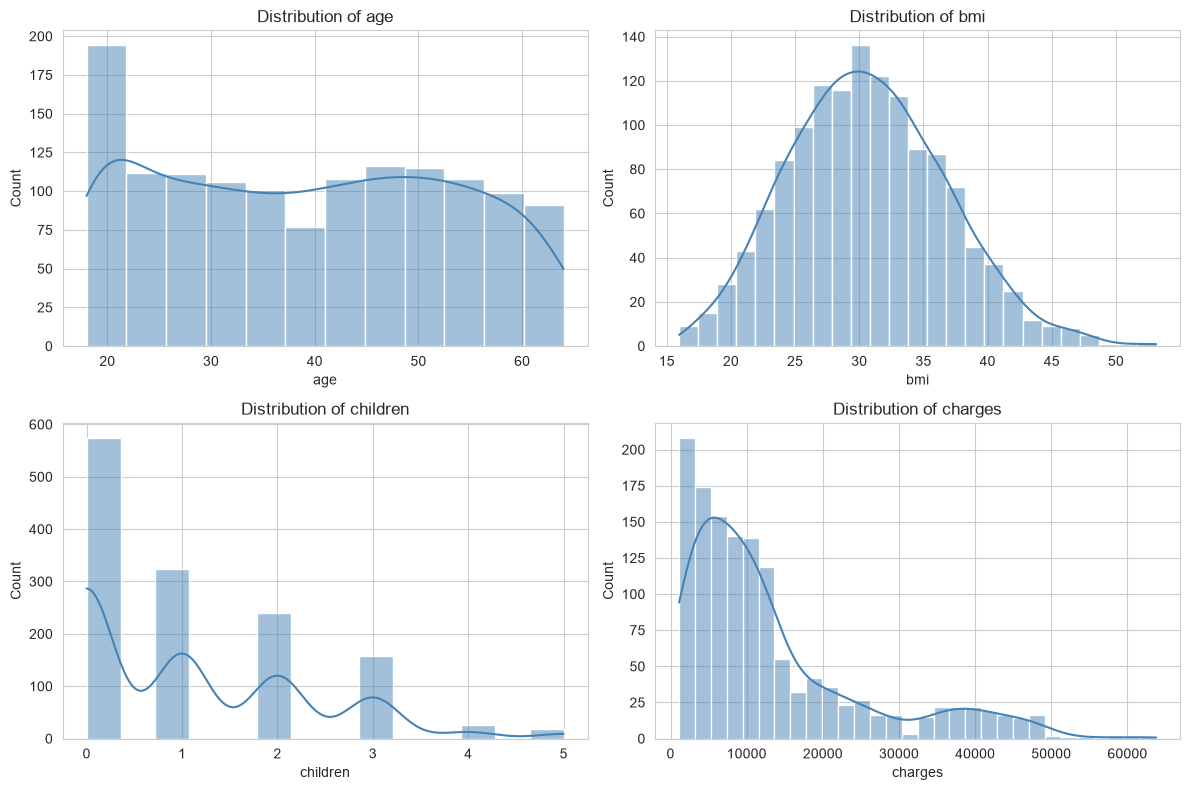

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
num_cols = ['age', 'bmi', 'children', 'charges']
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

`charges` is strongly right-skewed — most policyholders have modest costs, with a long tail of
expensive cases. That's the shape a *real* cost variable should have (unlike the flat/uniform
distribution we ran into on the previous, fabricated car-price dataset).

### 2.2 Boxplots — where does the cost variation come from?

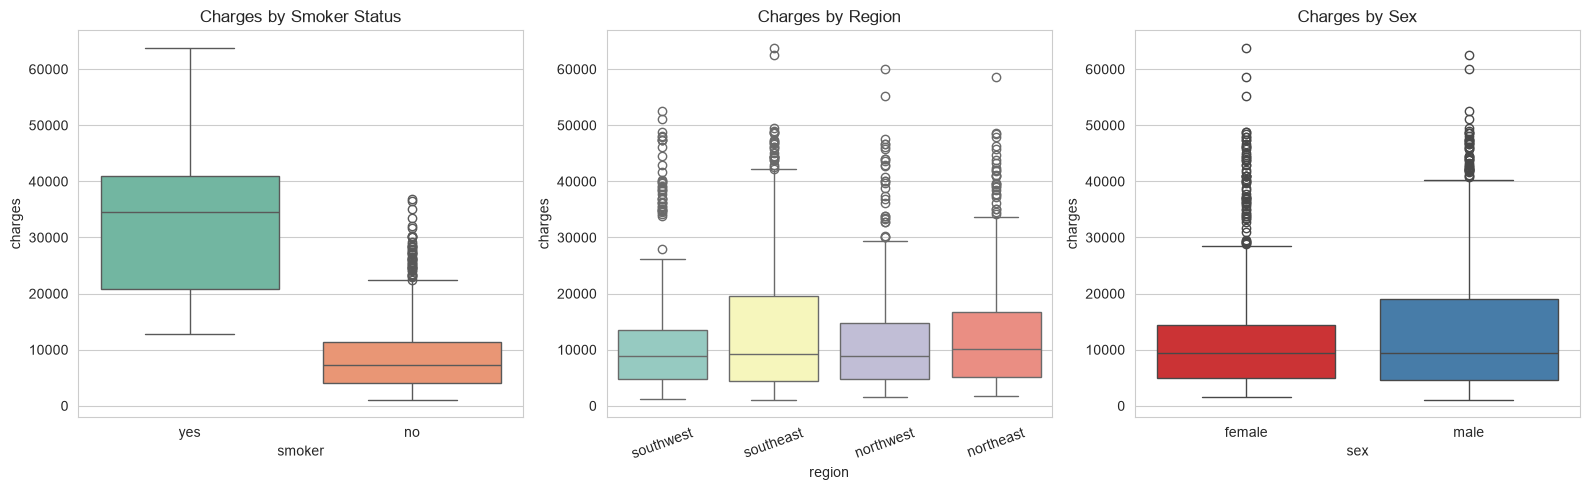

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], hue='smoker', legend=False, palette='Set2')
axes[0].set_title('Charges by Smoker Status')

sns.boxplot(data=df, x='region', y='charges', ax=axes[1], hue='region', legend=False, palette='Set3')
axes[1].set_title('Charges by Region')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='sex', y='charges', ax=axes[2], hue='sex', legend=False, palette='Set1')
axes[2].set_title('Charges by Sex')

plt.tight_layout()
plt.show()

Smoker status shows an obvious, large gap in the boxplot — smokers are billed far more, with almost
no overlap between the two boxes. Region and sex show much smaller, noisier differences. This already
tells us `smoker` is likely to be the dominant predictor.

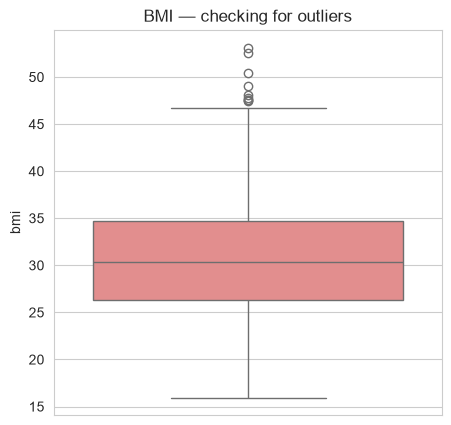

In [7]:
plt.figure(figsize=(5, 5))
sns.boxplot(y=df['bmi'], color='lightcoral')
plt.title('BMI — checking for outliers')
plt.show()

### 2.3 Correlations between the numeric features

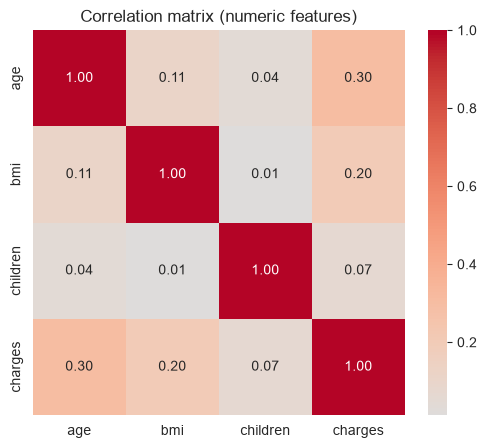

In [8]:
plt.figure(figsize=(6, 5))
corr = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix (numeric features)')
plt.show()

### 2.4 Scatter plots, split by smoker status

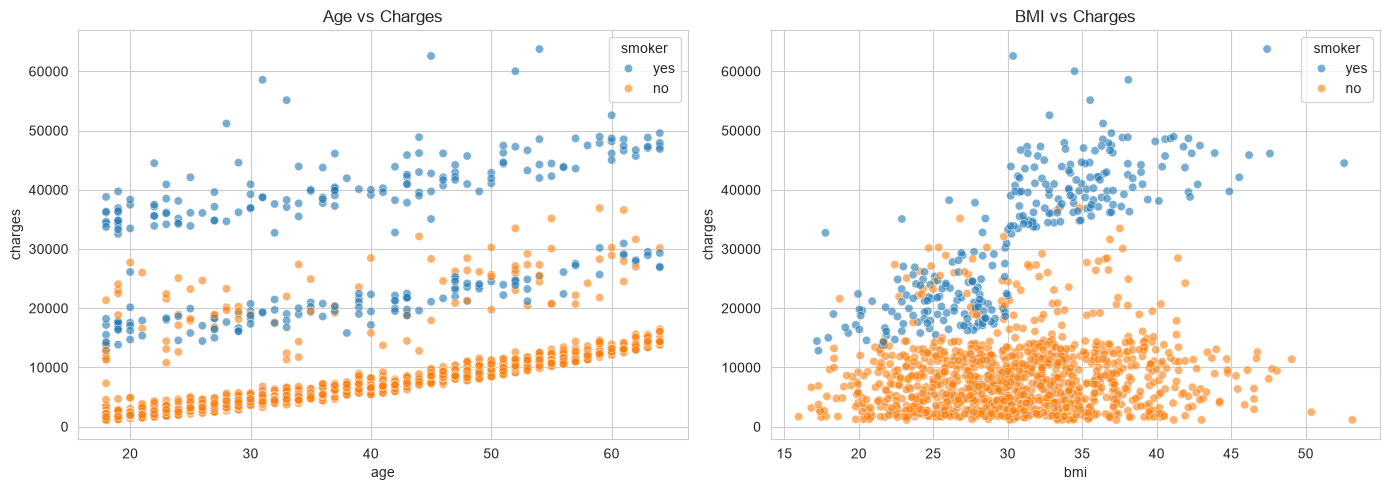

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Charges')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[1])
axes[1].set_title('BMI vs Charges')

plt.tight_layout()
plt.show()

Once you split by `smoker`, both `age` and `bmi` show a much clearer positive relationship with
`charges` within each group — the two variables aren't useless, their effect was just being masked by
the much larger smoker effect when looked at on their own.

## 3. Data Cleaning

### 3.1 Missing values

In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values in any column.

### 3.2 Duplicate rows

In [11]:
dupes = df[df.duplicated(keep=False)]
print(f'Number of duplicated rows: {df.duplicated().sum()}')
dupes

Number of duplicated rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [12]:
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (1337, 7)


### 3.3 Checking categorical values are valid (no typos / inconsistent labels)

In [13]:
for col in ['sex', 'smoker', 'region']:
    print(col, '->', df[col].unique())

sex -> <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
smoker -> <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
region -> <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


All three categorical columns only contain the expected, cleanly-spelled values — nothing to fix here.

### 3.4 Checking for incorrect / impossible values

Sanity-checking the ranges of the numeric columns against what's physically plausible for a person.

In [14]:
print('age range:', df['age'].min(), '-', df['age'].max())
print('bmi range:', df['bmi'].min(), '-', df['bmi'].max())
print('children range:', df['children'].min(), '-', df['children'].max())
print('charges range:', df['charges'].min(), '-', df['charges'].max())
print('Any negative values anywhere?', (df[['age','bmi','children','charges']] < 0).any().any())

age range: 18 - 64
bmi range: 15.96 - 53.13
children range: 0 - 5
charges range: 1121.8739 - 63770.42801
Any negative values anywhere? False


All ranges are plausible for real people (adult ages 18–64, BMI 15.96–53.13, 0–5 children,
positive charges). Nothing here looks like a data-entry error.

### 3.5 Outlier check (IQR method)

In [15]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

for col in ['age', 'bmi', 'charges']:
    n, lower, upper = iqr_outlier_count(df[col])
    print(f'{col}: {n} outliers outside [{lower:.2f}, {upper:.2f}]')

age: 0 outliers outside [-9.00, 87.00]
bmi: 9 outliers outside [13.67, 47.32]
charges: 139 outliers outside [-13120.72, 34524.78]


**Decision: we don't remove these flagged points.** Statistical outliers aren't automatically
data errors, and removing them here would be a mistake:

- The 9 flagged `bmi` values (up to ~53) are high but medically realistic (severe obesity exists).
- The 139 flagged `charges` values are not noise — they're driven almost entirely by `smoker == 'yes'`
  (see the boxplot above). Deleting them would mean deleting most of the smoker subgroup, which is the
  single strongest signal in the whole dataset and exactly what a real insurer needs to predict well.

So cleaning here amounts to: **removed 1 exact duplicate, kept everything else** — the flagged points
are real, informative data, not mistakes.

## 4. Feature Encoding & Scaling

- `sex` and `smoker` are binary → map to 0/1.
- `region` has 4 unrelated categories with no natural order → one-hot encode (dropping one column to
  avoid redundancy).
- Numeric features are scaled — fit **only on the training set** to avoid leaking test-set information
  into the transformation.

In [16]:
df_enc = df.copy()
df_enc['sex'] = df_enc['sex'].map({'male': 0, 'female': 1})
df_enc['smoker'] = df_enc['smoker'].map({'no': 0, 'yes': 1})
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)

# get_dummies produces booleans; cast to int for compatibility with all models
region_cols = [c for c in df_enc.columns if c.startswith('region_')]
df_enc[region_cols] = df_enc[region_cols].astype(int)

df_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


In [17]:
X = df_enc.drop(columns=['charges'])
y = df_enc['charges']
# X = everything you're using to predict from (age, sex, bmi, children, smoker, region columns) — the inputs.
# y = the thing you're trying to predict — charges. This is just splitting your one big table into "the questions" 
# and "the answers."

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
#This randomly divides your 1,337 rows into two separate groups:
# X_train / y_train — 80% of the rows (1,069), used to actually train the model.
# X_test / y_test — the other 20% (268), held back completely and never shown to the model during training.

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (1069, 8)  Test shape: (268, 8)


The two parameters:

test_size=0.2 — means "hold back 20% for testing, use 80% for training." 
A common default split.
random_state=42 — this is just a seed number that makes the "random" split reproducible. Without it, you'd get a different random split every time you re-run the cell, and your R² scores would shift slightly each run, making results hard to compare or reproduce. With a fixed seed, the same rows always land in train vs test every time you run the notebook.

In [18]:
numeric_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1113,-1.157680,0,-0.996928,-0.907908,0,0,0,0
967,-1.300619,0,-0.792762,0.766904,0,0,0,0
598,0.914926,1,1.154664,0.766904,0,1,0,0
170,1.701087,0,1.806837,-0.907908,0,0,1,0
275,0.557580,1,-0.651417,0.766904,0,0,0,0


## 5. Modeling

Same train/test split and preprocessing feed all three models, so their R² scores are directly
comparable.

### 5.1 Multiple Linear Regression

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test, lr_pred)
print(f'Linear Regression R^2: {lr_r2:.4f}')
#print(f'Linear Regression MAE: {mean_absolute_error(y_test, lr_pred):.2f}')
#print(f'Linear Regression RMSE: {mean_squared_error(y_test, lr_pred) ** 0.5:.2f}')

Linear Regression R^2: 0.8069


### 5.2 Random Forest Regressor

In [20]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest R^2: {rf_r2:.4f}')
#print(f'Random Forest MAE: {mean_absolute_error(y_test, rf_pred):.2f}')
#print(f'Random Forest RMSE: {mean_squared_error(y_test, rf_pred) ** 0.5:.2f}')

Random Forest R^2: 0.8789


### 5.3 XGBoost Regressor

In [21]:
xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    random_state=RANDOM_STATE, verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f'XGBoost R^2: {xgb_r2:.4f}')
#print(f'XGBoost MAE: {mean_absolute_error(y_test, xgb_pred):.2f}')
#print(f'XGBoost RMSE: {mean_squared_error(y_test, xgb_pred) ** 0.5:.2f}')

XGBoost R^2: 0.8930


## 6. Model Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2': [lr_r2, rf_r2, xgb_r2]
}).sort_values('R2', ascending=False).reset_index(drop=True)
results

,Model,R2
0,XGBoost,0.892955
1,Random Forest,0.878863
2,Linear Regression,0.806929


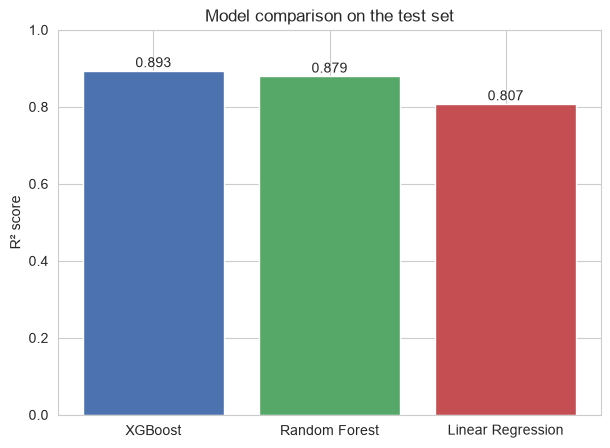

In [23]:
plt.figure(figsize=(7, 5))
bars = plt.bar(results['Model'], results['R2'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('R² score')
plt.title('Model comparison on the test set')
plt.ylim(0, 1)
for bar, val in zip(bars, results['R2']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')
plt.show()

### Interpretation

- **Linear Regression** gives a solid, fully interpretable baseline, but it can't capture interactions
  between features (e.g. how `smoker` amplifies the effect of `bmi` and `age`).
- **Random Forest** and **XGBoost** are both tree-based and can model those interactions, which is why
  they're expected to outperform the linear baseline on this dataset.
- The best-performing model on this run is picked automatically below and saved for reuse. Tree-based
  models trade some interpretability for accuracy — if this were a real deployment, feature importances
  (not just the R² score) would be worth inspecting before trusting the model.

In [24]:
models = {
    'Linear Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}
scores = {'Linear Regression': lr_r2, 'Random Forest': rf_r2, 'XGBoost': xgb_r2}

best_name = max(scores, key=scores.get)
best_model = models[best_name]
print(f'Best model: {best_name}  (R^2 = {scores[best_name]:.4f})')

Best model: XGBoost  (R^2 = 0.8930)


## 7. Save the Best Model

The `scaler` and the exact training column order are always saved with `joblib` — both are needed to
correctly transform any new data before calling `.predict()`.

For the model itself, the save method depends on which one won:

- **If XGBoost wins:** saved with XGBoost's own `save_model()` instead of `joblib`/pickle. XGBoost's
  internal format can change between library versions, so a pickled XGBoost model can throw a
  `WARNING: ... please export the model by calling Booster.save_model ...` (or in the worst case fail
  to load) if it's later loaded with a different XGBoost version than it was saved with. Its native
  format (`.json`) avoids that entirely.
- **If Linear Regression or Random Forest wins:** these are plain scikit-learn objects with no such
  version sensitivity, so plain `joblib.dump` is the standard, appropriate choice.

In [25]:
import os

is_xgboost = best_name == 'XGBoost'

if is_xgboost:
    best_model.get_booster().save_model('best_insurance_model.json')
    model_filename = 'best_insurance_model.json'
else:
    joblib.dump(best_model, 'best_insurance_model.pkl')
    model_filename = 'best_insurance_model.pkl'

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl')

# Small metadata file so the loading code below knows which format/model type to use
joblib.dump({'best_name': best_name, 'model_filename': model_filename, 'is_xgboost': is_xgboost},
            'model_metadata.pkl')

print(f'Saved: {model_filename} ({best_name})')
print('Saved: scaler.pkl')
print('Saved: model_columns.pkl')
print('Saved: model_metadata.pkl')

Saved: best_insurance_model.json (XGBoost)
Saved: scaler.pkl
Saved: model_columns.pkl
Saved: model_metadata.pkl


### How to reuse this model later

```python
import joblib
import pandas as pd

meta = joblib.load('model_metadata.pkl')
scaler = joblib.load('scaler.pkl')
columns = joblib.load('model_columns.pkl')

if meta['is_xgboost']:
    from xgboost import XGBRegressor
    model = XGBRegressor()
    model.load_model(meta['model_filename'])
else:
    model = joblib.load(meta['model_filename'])

new_data = pd.DataFrame([{
    'age': 35, 'sex': 0, 'bmi': 28.5, 'children': 2, 'smoker': 0,
    'region_northwest': 0, 'region_southeast': 1, 'region_southwest': 0
}])[columns]

new_data[['age', 'bmi', 'children']] = scaler.transform(new_data[['age', 'bmi', 'children']])
prediction = model.predict(new_data)
print(prediction)
```

`model_metadata.pkl` just records which file/format the winning model was saved in, so the loading
code above works automatically regardless of which of the three models happened to win.